In [5]:
import sys
import importlib
sys.path.insert(0, '/lustre/lrspec/users/4301/hxe-for-tda/hxetda')
import hxetda
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_recall_fscore_support
from sklearn.utils import class_weight
import numpy as np

sys.path.insert(0, '/lustre/lrspec/users/4301/Milligan_ABC-SN')
import heir_loss
from plot_data import *

# Notebook runing the keras version I made, this weights the sample like how is done in their example notebook

In [7]:
# Let's import preprocess our variable star data
scaler = StandardScaler()

# I am adding some conversions here for events which are either "candidates" or have <5 objects
conversions = {'SN Ia-91T-like':'SN Ia-91T', 'SN IIn-pec':'SN IIn', 'TDE-H-He':'TDE', 'SN IIP':'SN II', 
               'SN IIL': 'SN II', 'SN Iax[02cx-like]': 'SN Iax'}
#'SN I': 'SN Ia'
def make_dataset(load=False):
    # to do - eventually, I do want to save/load a dataset...
    if not load:
        metadata, all_labels = np.loadtxt('/lustre/lrspec/users/4301/hxe-for-tda/data/training_set_dynesty.csv',usecols=(0,1), 
                                          delimiter=',', skiprows=1, dtype=str, unpack=True)
        

        gind = np.where((all_labels !='Galaxy') & (all_labels !='Other') &  (all_labels !='M dwarf') & (all_labels !='SN I'))

        metadata = metadata[gind]
        all_labels = all_labels[gind]
        all_dat = np.zeros((len(all_labels),15))
        
        for key in conversions:
            gind = np.where(all_labels == key)
            all_labels[gind] = conversions[key]
        vertices = np.asarray(np.unique(all_labels),dtype=str)
        print(np.unique(all_labels, return_counts=True))
        vertices = np.append(vertices, ['StellarTransient', 'SN-like', 'ILOT', 'CC'])
        vertices = np.insert(vertices, 0, 'Object')

        print(metadata)

        for i, md in enumerate(metadata):
            # print(md)
            one_sn_data = np.load('/lustre/lrspec/users/4301/hxe-for-tda/data/dynesty_fits/'+md+'_eqwt_dynesty.npz')
            all_dat[i] = np.mean(one_sn_data['arr_0'],axis=0)
        return(all_labels,all_dat, vertices)

labels,all_features, vertices = make_dataset()
scaler.fit(all_features)
all_features = scaler.transform(all_features)

(array(['AGN', 'CV', 'ILRT', 'LBV', 'LRN', 'Nova', 'QSO', 'SLSN-I',
       'SLSN-II', 'SN', 'SN II', 'SN II-pec', 'SN IIb', 'SN IIn', 'SN Ia',
       'SN Ia-91T', 'SN Ia-91bg-like', 'SN Ia-CSM', 'SN Ia-SC',
       'SN Ia-pec', 'SN Iax', 'SN Ib', 'SN Ib-pec', 'SN Ib/c', 'SN Ibn',
       'SN Ic', 'SN Ic-BL', 'SN Ic-Ca-rich', 'SN Ic-pec', 'SN Icn', 'TDE',
       'Varstar'], dtype='<U17'), array([  47,  103,    1,    7,    1,   14,    4,   89,   49,   11,  957,
          4,   58,  196, 4173,  157,   24,   15,    3,   32,   12,   82,
          3,   14,   18,   92,   49,    1,    1,    2,   51,    8]))
['ZTF23aaitimz' 'ZTF23aaikcdx' 'ZTF23aaicagr' ... 'ZTF23aacdnjz'
 'ZTF23aacjeou' 'ZTF23aaetmwj']


In [8]:
# Tell me a little about the data...
ulab, counts = np.unique(labels, return_counts=True)
for x,y in zip(ulab, counts):
    print(x,y, y/np.sum(counts))
print('Features',np.shape(all_features))

AGN 47 0.007486460656259956
CV 103 0.01640649888499522
ILRT 1 0.00015928639694170118
LBV 7 0.0011150047785919083
LRN 1 0.00015928639694170118
Nova 14 0.0022300095571838167
QSO 4 0.0006371455877668047
SLSN-I 89 0.014176489327811405
SLSN-II 49 0.007805033450143358
SN 11 0.001752150366358713
SN II 957 0.15243708187320804
SN II-pec 4 0.0006371455877668047
SN IIb 58 0.009238611022618668
SN IIn 196 0.03122013380057343
SN Ia 4173 0.664702134437719
SN Ia-91T 157 0.025007964319847083
SN Ia-91bg-like 24 0.003822873526600828
SN Ia-CSM 15 0.002389295954125518
SN Ia-SC 3 0.0004778591908251035
SN Ia-pec 32 0.005097164702134438
SN Iax 12 0.001911436763300414
SN Ib 82 0.013061484549219496
SN Ib-pec 3 0.0004778591908251035
SN Ib/c 14 0.0022300095571838167
SN Ibn 18 0.002867155144950621
SN Ic 92 0.014654348518636508
SN Ic-BL 49 0.007805033450143358
SN Ic-Ca-rich 1 0.00015928639694170118
SN Ic-pec 1 0.00015928639694170118
SN Icn 2 0.00031857279388340236
TDE 51 0.00812360624402676
Varstar 8 0.001274291175

['Object' 'AGN' 'CV' 'ILRT' 'LBV' 'LRN' 'Nova' 'QSO' 'SLSN-I' 'SLSN-II'
 'SN' 'SN II' 'SN II-pec' 'SN IIb' 'SN IIn' 'SN Ia' 'SN Ia-91T'
 'SN Ia-91bg-like' 'SN Ia-CSM' 'SN Ia-SC' 'SN Ia-pec' 'SN Iax' 'SN Ib'
 'SN Ib-pec' 'SN Ib/c' 'SN Ibn' 'SN Ic' 'SN Ic-BL' 'SN Ic-Ca-rich'
 'SN Ic-pec' 'SN Icn' 'TDE' 'Varstar' 'StellarTransient' 'SN-like' 'ILOT'
 'CC']


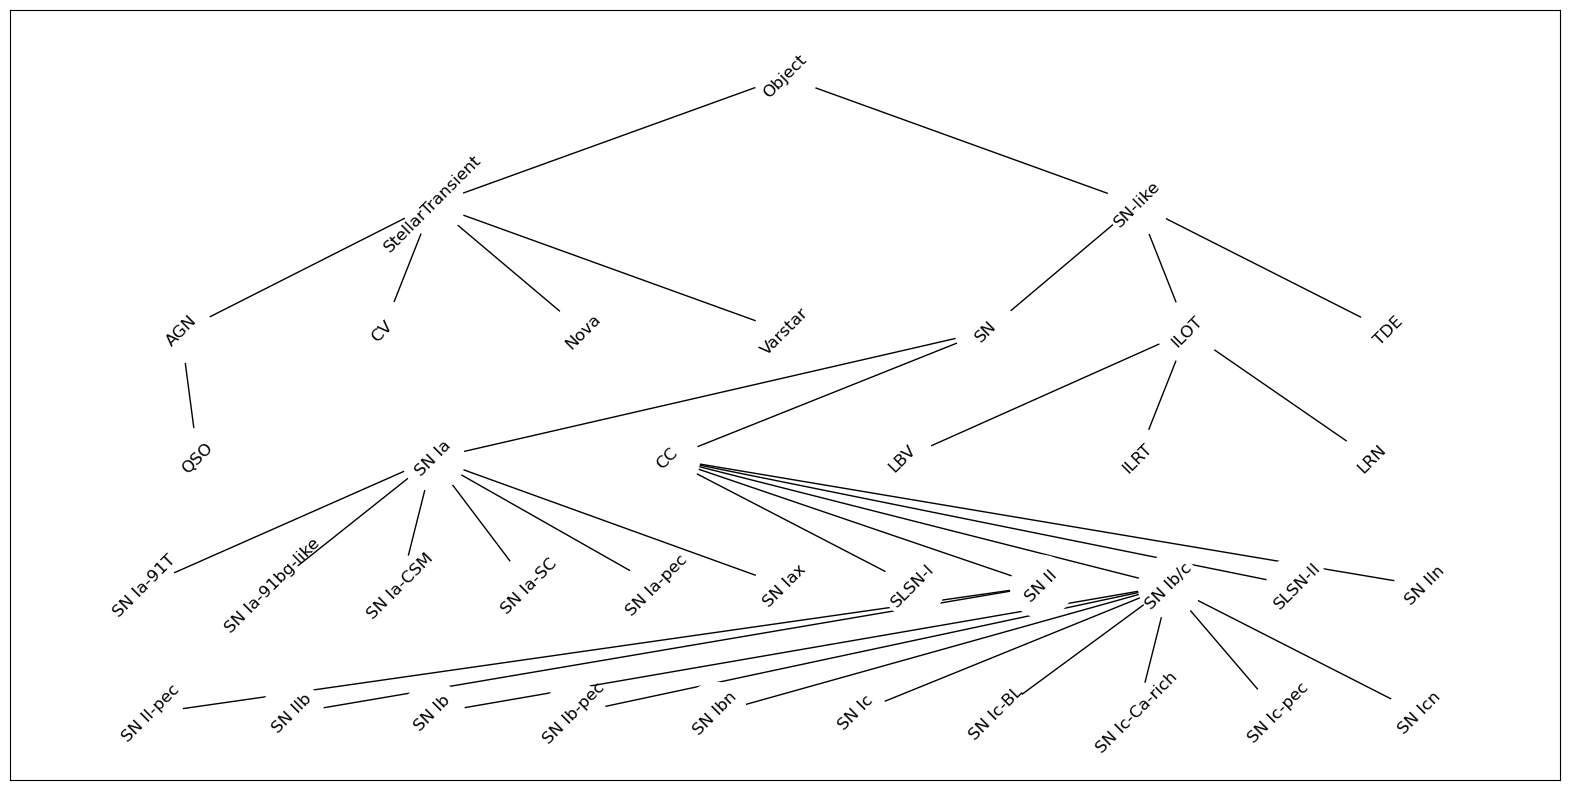

In [9]:
# Make a graph

print(vertices)
G=nx.DiGraph()

G.add_edge('Object','StellarTransient') #this does NOT include extragalactic transients
G.add_edge('Object','SN-like')


G.add_edge('StellarTransient','AGN')
G.add_edge('AGN','QSO')

G.add_edge('StellarTransient', 'CV')
G.add_edge('StellarTransient', 'Nova')
G.add_edge('StellarTransient', 'Varstar')

G.add_edge('SN-like', 'SN')
G.add_edge('SN-like', 'ILOT')
G.add_edge('ILOT', 'LBV')
G.add_edge('ILOT', 'ILRT')
G.add_edge('ILOT', 'LRN')
G.add_edge('SN-like', 'TDE')


G.add_edge('SN', 'SN Ia')
G.add_edge('SN Ia', 'SN Ia-91T')
G.add_edge('SN Ia', 'SN Ia-91bg-like')
G.add_edge('SN Ia', 'SN Ia-CSM')
G.add_edge('SN Ia', 'SN Ia-SC')
G.add_edge('SN Ia', 'SN Ia-pec')
G.add_edge('SN Ia', 'SN Iax')


G.add_edge('SN', 'CC')

G.add_edge('CC', 'SLSN-I')
G.add_edge('CC', 'SN II')

G.add_edge('CC', 'SN Ib/c')
G.add_edge('SN Ib/c', 'SN Ib')
G.add_edge('SN Ib/c', 'SN Ib-pec')
G.add_edge('SN Ib/c', 'SN Ibn')
G.add_edge('SN Ib/c', 'SN Ic')
G.add_edge('SN Ib/c', 'SN Ic-BL')
G.add_edge('SN Ib/c', 'SN Ic-Ca-rich')
G.add_edge('SN Ib/c', 'SN Ic-pec')
G.add_edge('SN Ib/c', 'SN Icn')

G.add_edge('CC', 'SLSN-II')
G.add_edge('SN II', 'SN II-pec')
G.add_edge('SN II', 'SN IIb')
G.add_edge('CC', 'SN IIn')

importlib.reload(hxetda)
pos = hxetda.hierarchy_pos(G, 'Object')

fig = plt.figure(1, figsize=(20, 10))

nx.draw_networkx(G, pos=pos, nodelist=vertices, node_color='white', with_labels=False, node_size=2000, arrows=False)
text = nx.draw_networkx_labels(G, pos)
for _, t in text.items():
    t.set_rotation(45) 

plt.show()

In [10]:
# Some pre-processing for the graph
paths, pathlengths, mask_list, y_dict = hxetda.calc_path_and_mask(G, vertices, 'Object')

In [11]:
# Some pre-processing for the hxetda class weights
class_weight_dict = hxetda.calc_class_weights(labels, vertices, paths)
class_weight_dict

weights = np.array([class_weight_dict[x] for x in labels])

In [35]:
class_weight_dict

{np.str_('AGN'): array([3.84681373]),
 np.str_('CV'): array([1.90473301]),
 np.str_('ILRT'): array([196.1875]),
 np.str_('LBV'): array([28.02678571]),
 np.str_('LRN'): array([196.1875]),
 np.str_('Nova'): array([14.01339286]),
 np.str_('QSO'): array([49.046875]),
 np.str_('SLSN-I'): array([2.20435393]),
 np.str_('SLSN-II'): array([4.00382653]),
 np.str_('SN'): array([0.03247062]),
 np.str_('SN II'): array([0.19252944]),
 np.str_('SN II-pec'): array([49.046875]),
 np.str_('SN IIb'): array([3.3825431]),
 np.str_('SN IIn'): array([1.00095663]),
 np.str_('SN Ia'): array([0.04442652]),
 np.str_('SN Ia-91T'): array([1.24960191]),
 np.str_('SN Ia-91bg-like'): array([8.17447917]),
 np.str_('SN Ia-CSM'): array([13.07916667]),
 np.str_('SN Ia-SC'): array([65.39583333]),
 np.str_('SN Ia-pec'): array([6.13085938]),
 np.str_('SN Iax'): array([16.34895833]),
 np.str_('SN Ib'): array([2.39253049]),
 np.str_('SN Ib-pec'): array([65.39583333]),
 np.str_('SN Ib/c'): array([0.74880725]),
 np.str_('SN Ibn

In [12]:
# Set up for train test split...
labels_new = [y_dict[x] for x in labels]
weights = [class_weight_dict[x] for x in labels]
X_train, X_test, y_train, y_test, labels_train, labels_test, weights_train, weights_test = train_test_split(all_features, labels_new, labels, weights,
                                                                                                            test_size=0.33, random_state = 7)
# X_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
# X_test = tf.convert_to_tensor(X_test, dtype=tf.float32)
# y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)
# y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)

# weights_train = tf.convert_to_tensor(weights_train, dtype=tf.float32)
# weights_test = tf.convert_to_tensor(weights_test, dtype=tf.float32)

X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

weights_train = np.array(weights_train)
weights_test = np.array(weights_test)


print(np.shape(X_train))

(4206, 15)


In [13]:
from tensorflow import keras
from keras import layers

class Feedforward(keras.Model):
    def __init__(self, input_size, hidden_size, output_size):
        super(Feedforward, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        
        # Define layers
        self.fc1 = layers.Dense(hidden_size, activation='sigmoid', input_shape=(input_size,))
        self.fc2 = layers.Dense(hidden_size, activation='sigmoid')
        self.fc3 = layers.Dense(output_size)
        
    def call(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        return x

# Running using sample weights

4206
1 -0.17015553 -0.22156197
11 -0.5003229 -0.5654851
21 -0.5783632 -0.6430479
31 -0.62949854 -0.6831424
41 -0.6662627 -0.70762753
51 -0.6900284 -0.72250724
61 -0.7061795 -0.7309442
71 -0.7197503 -0.7376014
81 -0.7328317 -0.74279237
91 -0.7454123 -0.7464996
101 -0.7549348 -0.75014055
111 -0.7629939 -0.7531685
121 -0.7701697 -0.7558003
131 -0.77674985 -0.75822425
141 -0.7829415 -0.7604887
151 -0.7888988 -0.76254594
161 -0.7946602 -0.7644715
171 -0.80044353 -0.7663294
181 -0.8064707 -0.7681487
191 -0.8126524 -0.76994634
201 -0.81903344 -0.7717412
211 -0.82513875 -0.7735981
221 -0.8307263 -0.7757453
231 -0.83591604 -0.7785644
241 -0.8407444 -0.78099084
251 -0.8453063 -0.78235215
261 -0.8496538 -0.78315693
271 -0.8537865 -0.7840155
281 -0.85777193 -0.784859
291 -0.86167634 -0.78567463
301 -0.8655343 -0.7863801
311 -0.86935985 -0.786914
321 -0.8731269 -0.7872376
331 -0.8768022 -0.7873168
341 -0.88043284 -0.7871436
351 -0.8841169 -0.7867781
361 -0.88790536 -0.7863185
371 -0.8917499 -0.7858

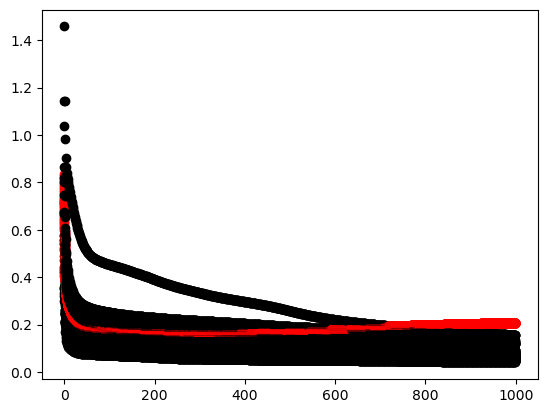

In [15]:
import tensorflow as tf


# Create and compile the model
model = Feedforward(np.shape(X_test[0])[0], 15, len(vertices))

# Use AdamW optimizer in Keras (equivalent to torch.optim.AdamW)
optimizer = keras.optimizers.AdamW(learning_rate=0.001)

# my loss function 
loss_fn = heir_loss.WeightedHierchicalLoss_hxetda(mask_list, pathlengths, alpha=0.5)

# Compile the model - we'll use a custom training loop since you have custom loss
# Note: We won't use model.compile() since we need custom training loop

epochs = 1000
batch_size = 128
n_batches = len(X_train) // batch_size + (1 if len(X_train) % batch_size != 0 else 0)

print(len(X_train))

# Lists to store loss values for plotting
loss_history = []
loss2_history = []

for epoch in range(epochs):
    if epoch % 10 == 1:
        if loss_history and loss2_history:
            print(epoch, np.log10(loss_history[-1]), np.log10(loss2_history[-1]))
    
    # # Shuffle data at the beginning of each epoch (optional but recommended)
    # indices = np.random.permutation(len(X_train))
    # X_train_shuffled = X_train[indices]
    # y_train_shuffled = y_train[indices]
    # weights_train_shuffled = weights_train[indices]
    
    for i in range(n_batches):
        # Local batches and labels
        local_X = X_train[i*batch_size:(i+1)*batch_size]
        local_y = y_train[i*batch_size:(i+1)*batch_size]
        local_weights = weights_train[i*batch_size:(i+1)*batch_size]
        
        # # Convert to tensors if needed (Keras works with numpy arrays too)
        # local_X = tf.convert_to_tensor(local_X, dtype=tf.float32)
        # local_y = tf.convert_to_tensor(local_y, dtype=tf.float32)
        # local_weights = tf.convert_to_tensor(local_weights, dtype=tf.float32)
        
        # Forward pass using GradientTape for automatic differentiation
        with tf.GradientTape() as tape:
            y_pred = model(local_X, training=True)
            # Compute Loss - your custom loss function
            loss = loss_fn(local_y, y_pred, sample_weight=local_weights)
        
        # Get gradients
        gradients = tape.gradient(loss, model.trainable_variables)
        # Apply gradients
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        
        # Store loss
        loss_history.append(loss.numpy())
        
        # Plot training loss
        plt.plot(epoch, loss.numpy(), 'ko')
        
        # Compute test loss
        ypred2 = model(X_test, training=False)
        loss2 = loss_fn(y_test, ypred2, weights_test)
        loss2_history.append(loss2.numpy())
        
        # Plot test loss
        plt.plot(epoch, loss2.numpy(), 'ro')

plt.show()

### Note weird stripes in loss I believe are due to not shuffling data, in order to show the same results I didn't change this for this proof of concept


In [16]:
# model.eval()
y_pred = model(X_test)
y_pred = torch.Tensor(np.array(y_pred))

['SN Ic' 'SN Ib' 'SN Ib' 'SN Ia' 'SN Ic-BL' 'SN II' 'SN Ia-91bg-like'
 'SN Ia' 'SN Ia' 'SN Ia' 'SN II' 'SN Ic' 'SN II' 'SN Ia-91bg-like' 'SN II'
 'SN Ic-BL' 'SN Ia' 'SN Ic' 'SN Ia-91bg-like' 'SN Ic-BL' 'SN Ic-BL'
 'SN IIb' 'SN Ib' 'SN Ia' 'SN Ia' 'SN II' 'SN Ib' 'SN Ia' 'SN Ib' 'SN II'
 'SN Ic' 'SN Ia' 'SN Ia' 'SN Ia' 'SN Ib' 'SN Ia' 'SN Ia' 'SN Ia-91bg-like'
 'SN II' 'SN Ic' 'SN Ia' 'SN Ic-BL' 'SN Ia' 'SN Ib' 'SN Ia-91bg-like'
 'SN Ia' 'SN Ia' 'SN Ic-BL' 'SN Ia' 'SN Ic-BL' 'SN Ic' 'SN Ia' 'SN Ia'
 'SN Ib' 'SN Ic' 'SN Ia' 'SN Ic' 'SN Ia' 'SN IIb' 'SN Iax' 'SN IIb'
 'SN Ia' 'SN Ic' 'SN II' 'SN Ib-pec' 'SN Ic-BL' 'SN IIb' 'SN Ib' 'SN II'
 'SN IIb' 'SN II' 'SN Ic-BL' 'SN IIb' 'SN Ic' 'SN Ia' 'SN Ia' 'SN Ia'
 'SN Ib/c' 'SN Iax' 'SN Ib' 'SN Ib' 'SN Ia-91bg-like' 'SN Ia' 'SN Ic'
 'SN Ic' 'SN Ia' 'SN Ia' 'SN Ia' 'SN Ia' 'SN Ib' 'SN Ic' 'SN Iax' 'SN II'
 'SN Ia-pec' 'SN II']
31


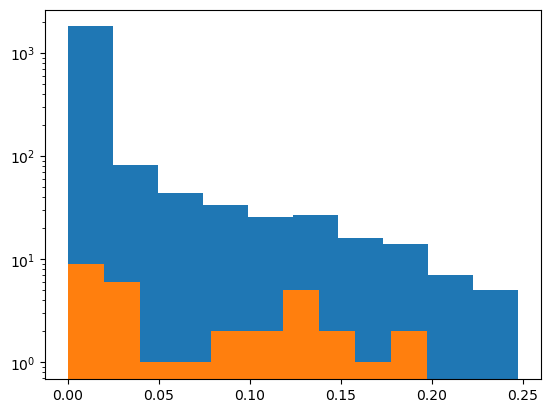

In [17]:
#Play around with different classes
specific_class = 'SN Ib'
single_class_prob = hxetda.get_prob(y_pred,specific_class, paths, vertices, mask_list).detach().numpy()
plt.hist(single_class_prob)
plt.yscale('log')

gind = np.where(single_class_prob>0.1)
print(labels_test[gind])
gind2 = np.where(labels_test == specific_class)
plt.hist(single_class_prob[gind2])
print(len(gind2[0]))


# 5-way task

/tmp/ipykernel_25083/3637076730.py:19: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  gind = np.where(np.in1d(fiveleaf_labels_test,leaves))[0]


1865
['SN Ia' 'SN Ib/c' 'SN II' 'SLSN-I' 'SN IIn']
SN Ia [0.11334694 0.00854091 0.09565949 0.06649872 0.4961639 ]
(0.5511009003491407, 0.45349810086577264, 0.4787336756833557, None)
(0.8487935656836462, 0.8487935656836462, 0.8487935656836462, None)


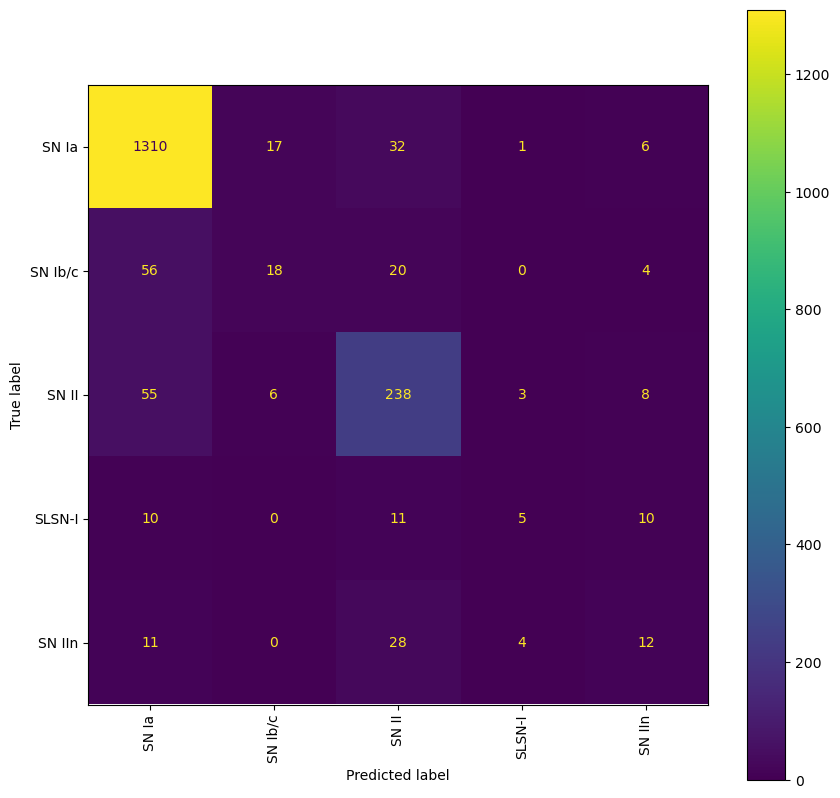

In [18]:
# 5-way task...
# Get my leaves...
importlib.reload(hxetda)

leaves = np.asarray(['SN Ia','SN Ib/c', 'SN II', 'SLSN-I', 'SN IIn'], dtype=str)
probs_list = np.zeros((len(y_pred), len(leaves)))
for i,leaf in enumerate(leaves):
    probs_list[:,i] = hxetda.get_prob(y_pred,leaf, paths, vertices, mask_list).detach().numpy()

my_predicted_types = leaves[np.argmax(probs_list,axis=1)]

fiveleaf_labels_test = np.copy(labels_test)

for i,s in enumerate(fiveleaf_labels_test):
    is_Ibc = hxetda.is_parent(s, 'SN Ib/c', vertices, paths)
    if is_Ibc:
        fiveleaf_labels_test[i] = 'SN Ib/c'

gind = np.where(np.in1d(fiveleaf_labels_test,leaves))[0]
cm = confusion_matrix(fiveleaf_labels_test[gind], my_predicted_types[gind], labels=leaves)
disp = ConfusionMatrixDisplay(cm, display_labels=leaves)
fig, ax = plt.subplots(figsize=(10,10))
disp.plot(xticks_rotation='vertical', ax=ax)
print(len(gind))
print(leaves)
print(labels_test[gind][9], probs_list[gind][9])

print(precision_recall_fscore_support(fiveleaf_labels_test[gind], my_predicted_types[gind],average='macro'))
print(precision_recall_fscore_support(fiveleaf_labels_test[gind], my_predicted_types[gind],average='micro'))

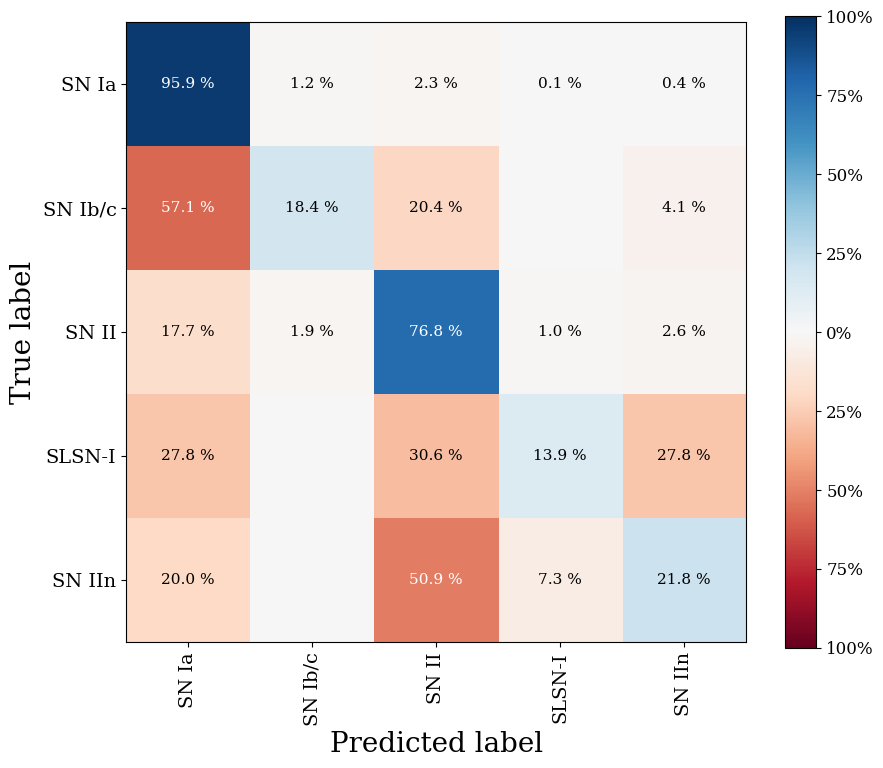

In [19]:
plot = plot_cm(cm, leaves)

In [20]:
cm

array([[1310,   17,   32,    1,    6],
       [  56,   18,   20,    0,    4],
       [  55,    6,  238,    3,    8],
       [  10,    0,   11,    5,   10],
       [  11,    0,   28,    4,   12]])

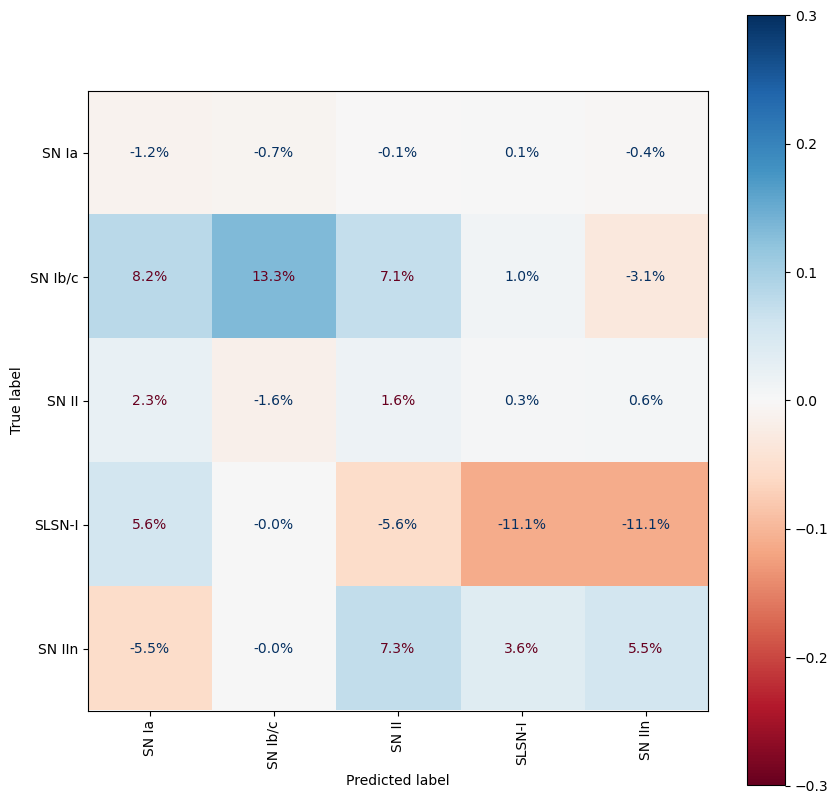

In [32]:
# just a copy of their confusion matrix in the 
their_cm = np.array([[1326,    7,   31,    2,    0],
                   [  64,    5,   27,    1,    1],
                   [  62,    1,  233,    4,   10],
                   [  12,    0,    9,    9,    6],
                   [   8,    0,   32,    6,    9]])
difference_cm = (cm - their_cm) # negative means mine did worse
difference_cm = difference_cm.astype("float") / np.nansum(their_cm, axis=1)[:, np.newaxis]
off_diag = ~np.eye(cm.shape[0], dtype=bool)
difference_cm[off_diag] *= -1
disp = ConfusionMatrixDisplay(difference_cm, display_labels=leaves)
fig, ax = plt.subplots(figsize=(10,10))
disp.plot(xticks_rotation='vertical', ax=ax, cmap = "RdBu", 
          im_kw={'vmin': -.3, 'vmax': .3}, values_format= ".1%")

### red/negative means this model did worse than theres, this seems all in line within reason to me

In [22]:
from sklearn.metrics import classification_report

cr = (classification_report(
    fiveleaf_labels_test[gind], my_predicted_types[gind], 
    target_names=leaves))

print(cr) 

              precision    recall  f1-score   support

       SN Ia       0.38      0.14      0.20        36
     SN Ib/c       0.72      0.77      0.74       310
       SN II       0.30      0.22      0.25        55
      SLSN-I       0.91      0.96      0.93      1366
      SN IIn       0.44      0.18      0.26        98

    accuracy                           0.85      1865
   macro avg       0.55      0.45      0.48      1865
weighted avg       0.82      0.85      0.83      1865



# stopping here as below they use Cross Entropy instead of their custom loss

In [60]:
# # Now for the same training/test set...train a baseline
# # Train!

# gind = np.where(np.in1d(fiveleaf_labels_test,leaves))[0]
# baseline_Xtest = X_test[gind]
# baseline_ytest = y_test[gind]
# baseline_labels_test = fiveleaf_labels_test[gind]

# print(len(gind))

# gind = np.where(np.in1d(labels_train,leaves))[0]
# baseline_Xtrain = X_train[gind]
# baseline_ytrain = y_train[gind]
# baseline_labels_train = labels_train[gind]

# # Now only keep relevant columns...

# new_baseline_ytest = np.zeros((len(baseline_ytest), len(leaves)))
# new_baseline_ytrain = np.zeros((len(baseline_ytrain), len(leaves)))

# for i,leaf in enumerate(leaves):
#     j = np.where(leaf == vertices)[0][0]
#     new_baseline_ytrain[:,i] = baseline_ytrain[:,j]
#     new_baseline_ytest[:,i] = baseline_ytest[:,j]

# baseline_ytrain = torch.tensor(new_baseline_ytrain)
# baseline_ytest = torch.tensor(baseline_ytest)

# model_baseline = hxetda.Feedforward(np.shape(X_test[0])[0],15, len(leaves))
# optimizer = torch.optim.AdamW(model_baseline.parameters(), lr = 0.01)
# model_baseline.train()
# epoch = 2000
# n_batches = 1024


# #class_weights=class_weight.compute_class_weight('balanced',classes=np.unique(labels_test),y=my_predicted_types)

# myloss = torch.nn.CrossEntropyLoss()

# for epoch in range(epoch):
# 	for i in range(int(len(baseline_Xtrain)/n_batches)+1):
# 		# Local batches and labels
# 		local_X, local_y = baseline_Xtrain[i*n_batches:(i+1)*n_batches,], baseline_ytrain[i*n_batches:(i+1)*n_batches,]
# 		optimizer.zero_grad()
# 		# Forward pass
# 		y_pred_baseline = model_baseline(local_X)
# 		# Compute Loss
# 		loss = myloss(y_pred_baseline,local_y)
# 		# Backward pass
# 		loss.backward()
# 		optimizer.step()
# 		plt.plot(epoch,loss.detach().numpy(),'ko')
# 	#scheduler.step()
# plt.show()

In [ ]:
# model_baseline.eval()
# y_pred_baseline = model_baseline(baseline_Xtest).detach().numpy()
# predicted_baseline_types = leaves[np.argmax(y_pred_baseline,axis=1)]
# cm = confusion_matrix(baseline_labels_test, predicted_baseline_types, labels=leaves)
# disp = ConfusionMatrixDisplay(cm, display_labels=leaves)
# fig, ax = plt.subplots(figsize=(10,10))
# disp.plot(xticks_rotation='vertical', ax=ax)

# print(precision_recall_fscore_support(baseline_labels_test, predicted_baseline_types,average='macro'))
# print(precision_recall_fscore_support(baseline_labels_test, predicted_baseline_types,average='micro'))

## Sibling task

In [61]:
# importlib.reload(hxetda)

# siblings = np.asarray(['StellarTransient', 'SN-like'])
# probs_list = np.zeros((len(y_pred), len(siblings)))
# for i,sib in enumerate(siblings):
#     probs_list[:,i] = hxetda.get_prob(y_pred,sib, paths, vertices, mask_list).detach().numpy()

# my_predicted_types = siblings[np.argmax(probs_list,axis=1)]

# sibling_labels_test = np.copy(labels_test)
# for i,s in enumerate(sibling_labels_test):
#     is_StellarTransient = hxetda.is_parent(s, 'StellarTransient', vertices, paths)

#     if is_StellarTransient:
#         sibling_labels_test[i] = 'StellarTransient'
#     else:
#         sibling_labels_test[i] = 'SN-like'


# cm = confusion_matrix(sibling_labels_test, my_predicted_types, labels=siblings)
# disp = ConfusionMatrixDisplay(cm, display_labels=siblings)
# fig, ax = plt.subplots(figsize=(10,10))
# disp.plot(xticks_rotation='vertical', ax=ax)

# print(precision_recall_fscore_support(sibling_labels_test, my_predicted_types,average='macro'))
# print(precision_recall_fscore_support(sibling_labels_test, my_predicted_types,average='micro'))

In [ ]:
# # And now baseline...
# # Now for the same training/test set...train a baseline
# # Train!

# siblings = np.asarray(['StellarTransient', 'SN-like'])

# baseline_ytest = np.zeros((len(y_test), len(siblings)))
# sibling_labels_test = np.copy(labels_test)
# for i,s in enumerate(sibling_labels_test):
#     is_StellarTransient = hxetda.is_parent(s, 'StellarTransient', vertices, paths)

#     if is_StellarTransient:
#         sibling_labels_test[i] = 'StellarTransient'
#         baseline_ytest[i,0] = 1

#     else:
#         sibling_labels_test[i] = 'SN-like'
#         baseline_ytest[i,1] = 1



# baseline_ytrain = np.zeros((len(y_train), len(siblings)))
# sibling_labels_train = np.copy(labels_train)
# for i,s in enumerate(sibling_labels_train):
#     is_StellarTransient = hxetda.is_parent(s, 'StellarTransient', vertices, paths)

#     if is_StellarTransient:
#         sibling_labels_train[i] = 'StellarTransient'
#         baseline_ytrain[i,0] = 1

#     else:
#         sibling_labels_train[i] = 'SN-like'
#         baseline_ytrain[i,1] = 1


# baseline_ytrain = torch.tensor(baseline_ytrain)
# baseline_ytest = torch.tensor(baseline_ytest)

# model_baseline = hxetda.Feedforward(np.shape(X_test[0])[0],15, len(siblings))
# optimizer = torch.optim.AdamW(model_baseline.parameters(), lr = 0.05)
# model_baseline.train()
# epoch = 1000
# n_batches = 1024

# baseline_Xtrain = torch.tensor(np.copy(X_train))
# baseline_Xtest = torch.tensor(np.copy(X_test))

# myloss = torch.nn.CrossEntropyLoss()

# for epoch in range(epoch):
# 	for i in range(int(len(baseline_Xtrain)/n_batches)+1):
# 		# Local batches and labels
# 		local_X, local_y = baseline_Xtrain[i*n_batches:(i+1)*n_batches,], baseline_ytrain[i*n_batches:(i+1)*n_batches,]
# 		optimizer.zero_grad()
# 		# Forward pass
# 		y_pred_baseline = model_baseline(local_X)
# 		# Compute Loss
# 		loss = myloss(y_pred_baseline,local_y)
# 		# Backward pass
# 		loss.backward()
# 		optimizer.step()
# 		plt.plot(epoch,loss.detach().numpy(),'ko')
# plt.show()

In [ ]:
# model_baseline.eval()
# y_pred_baseline = model_baseline(baseline_Xtest).detach().numpy()
# predicted_baseline_types = siblings[np.argmax(y_pred_baseline,axis=1)]
# cm = confusion_matrix(sibling_labels_test, predicted_baseline_types, labels=siblings)
# disp = ConfusionMatrixDisplay(cm, display_labels=siblings)
# fig, ax = plt.subplots(figsize=(10,10))
# disp.plot(xticks_rotation='vertical', ax=ax)

# print(precision_recall_fscore_support(sibling_labels_test, predicted_baseline_types,average='macro'))
# print(precision_recall_fscore_support(sibling_labels_test, predicted_baseline_types,average='micro'))